In [1]:
import torchvision
from torchvision import transforms
import torchvision.datasets as datasets
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter # to print to tensorboard
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import csv
import pandas as pd

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
lr = 4e-5
BATCH_SIZE = 64
EPOCHS = 30
LOG_STEP = 625
BETA1 = 0.5

LATENT_DIM = 128
image_dimension = 28 * 28 * 1 
myTransforms = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,), (0.5,))])

In [3]:
print("loading MNIST digits dataset")
dataset = datasets.MNIST(root="dataset/", transform=myTransforms, download=True)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)


loading MNIST digits dataset


In [16]:
def plot_samples(real_batch):
    real_grid = torchvision.utils.make_grid(real_batch, nrow=8, normalize=True, padding=1)
    real_grid_np = real_grid.permute(1, 2, 0).cpu().numpy()

    # Plot
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(real_grid_np, cmap="gray")
    ax.axis("off")
    ax.set_title("Real Samples", fontsize=10)

    plt.savefig("real_samples.png", dpi=300)
    plt.show()

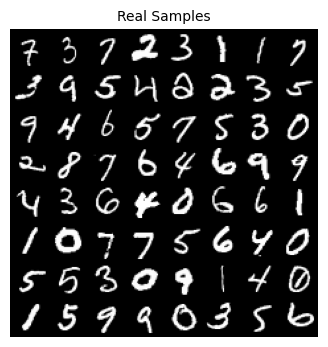

In [19]:
images, labels = next(iter(loader))
plot_samples(images)

## Vanilla GAN

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()

        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 256*7*7),
            nn.BatchNorm1d(256*7*7),
            nn.ReLU(True)
        )
        
        self.conv_blocks = nn.Sequential(
        
        # 256 x 7 x 7

            nn.ConvTranspose2d(256, 256, kernel_size=4, stride=2, padding=1, bias = False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

        # 256 x 14 x 14

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias = False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

        # 128 x 28 x 28

            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias = False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

        # 128 x 28 x 28

            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1, bias = False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

        # 64 x 28 x 28

            nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1, bias = False),
            nn.Tanh()

        # 1 x 28 x 28
        )
    
    def forward(self, z):
        x = self.fc(z)
        x = x.view(z.size(0), 256, 7, 7)
        x = self.conv_blocks(x)
        return x



class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.main = nn.Sequential(

            # 1 x 28 x 28

            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias = False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),

            # 64 x 14 x 14

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias = False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace = True),
            nn.Dropout2d(0.25),

            # 128 x 7 x 7

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias = False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace = True),
            nn.Dropout2d(0.25),

            # 256 x 4 x 4
            
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=0, bias = False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace = True),

            # 512 x 2 x 2 
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512*2*2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.main(x)
        return self.fc(x)

In [6]:
# initialize networks and optimizers
discriminator = Discriminator().to(device)
generator = Generator(latent_dim=LATENT_DIM).to(device)
opt_discriminator = optim.Adam(discriminator.parameters(), lr=lr)
opt_generator = optim.Adam(generator.parameters(), lr=2.5*lr)

# This is a binary classification task, so we use Binary Cross Entropy Loss
criterion = nn.BCELoss()
# Fixed noise for consistent TensorBoard visualization across steps
fixed_noise = torch.randn(BATCH_SIZE, LATENT_DIM).to(device)

In [7]:
writer_fake = SummaryWriter("runs/GAN_MNIST/fake")
writer_real = SummaryWriter("runs/GAN_MNIST/real")

In [8]:
def save_epoch_snapshot(generator, fixed_noise, epoch, device, save_dir = "plots/progression"):
    os.makedirs(save_dir, exist_ok=True)

    generator.eval()
    with torch.no_grad():
        fake = generator(fixed_noise)  # (16, 1, 28, 28)

    # make_grid: nrow=4 gives a 4x4 layout
    # normalize=True rescales from [-1,1] back to [0,1] for display
    grid = torchvision.utils.make_grid(fake, nrow=8, normalize=True, padding=2)
    grid_np = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(4, 4))
    plt.imshow(grid_np, cmap="gray")
    plt.axis("off")
    plt.title(f"Epoch {epoch:03d}", fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir,f"epoch_{epoch:03d}.png"), dpi=100, bbox_inches="tight")
    plt.close()  # close so we don't accumulate 100 open figures in memory

    generator.train()




In [9]:
step = 0
print("Started Training and visualization...")

log_path = "vanilla_gan_losses.csv"

if not os.path.exists(log_path):
    with open(log_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["epoch", "G_loss", "D_loss"])

# Just noise
save_epoch_snapshot(generator, fixed_noise, epoch=0, device=device, save_dir= "plots/progression_vanilla")

for epoch in range(EPOCHS):
    print()
    for batch_idx, (real, _) in enumerate(loader):
        # First we train the discriminator on real images vs. generated images

        # Get the real images and flatten them
        # for simplicity, we flatten the image to a vector and to use simple MLP networks
        # 28 * 28 * 1 flattens to 784
        real = real.to(device)
        batch_size = real.shape[0]

        # Step 1) generate fake images
        noise = torch.randn(batch_size, LATENT_DIM).to(device)
        fake = generator(noise)

        # Step 2) Train Discriminator:
        disc_real = discriminator(real)
        loss_disc_real = criterion(disc_real, torch.ones_like(disc_real))

        disc_fake = discriminator(fake.detach())  # detach: don't update G here
        loss_disc_fake = criterion(disc_fake, torch.zeros_like(disc_fake))

        loss_discriminator = (loss_disc_real + loss_disc_fake) / 2
        opt_discriminator.zero_grad()
        loss_discriminator.backward(retain_graph=True)
        opt_discriminator.step()

        # Train Generator:
        disc_fake_for_gen = discriminator(fake)
        loss_generator = criterion(disc_fake_for_gen, torch.ones_like(disc_fake_for_gen))

        opt_generator.zero_grad()
        loss_generator.backward()
        opt_generator.step()

        # print the progress
        print(f"\rEpoch [{epoch+1}/{EPOCHS}] Batch {batch_idx}/{len(loader)} \ Loss discriminator: {loss_discriminator:.4f}, loss generator: {loss_generator:.4f}", end="")

        # Log the losses and example images to tensorboard
        if batch_idx % LOG_STEP == 0:
            with torch.no_grad():
                # Generate noise via Generator, we always use the same noise to see the progression
                fake = generator(fixed_noise).reshape(-1, 1, 28, 28)
                # Get real data
                data = real.reshape(-1, 1, 28, 28)
                # make grid of pictures and add to tensorboard
                imgGridFake = torchvision.utils.make_grid(fake, normalize=True)
                imgGridReal = torchvision.utils.make_grid(real, normalize=True)

                writer_fake.add_image("MNIST Fake Images", imgGridFake, global_step=step)
                writer_real.add_image("MNIST Real Images", imgGridReal, global_step=step)
                writer_fake.add_scalar("Loss/Generator", loss_generator, global_step=step)
                writer_real.add_scalar("Loss/Discriminator", loss_discriminator, global_step=step)

                # increment step
                step += 1

    with open(log_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([epoch, loss_generator.item(), loss_discriminator.item()])

    # Save a snapshot at the end of every epoch
    save_epoch_snapshot(generator, fixed_noise, epoch=epoch+1, device=device, save_dir="plots/progression_vanilla")

Started Training and visualization...

Epoch [1/30] Batch 937/938 \ Loss discriminator: 0.7246, loss generator: 0.7919
Epoch [2/30] Batch 937/938 \ Loss discriminator: 0.5523, loss generator: 1.4221
Epoch [3/30] Batch 937/938 \ Loss discriminator: 0.5595, loss generator: 0.9311
Epoch [4/30] Batch 937/938 \ Loss discriminator: 0.8471, loss generator: 0.9396
Epoch [5/30] Batch 937/938 \ Loss discriminator: 0.7218, loss generator: 0.9541
Epoch [6/30] Batch 937/938 \ Loss discriminator: 0.6391, loss generator: 1.1495
Epoch [7/30] Batch 937/938 \ Loss discriminator: 0.6025, loss generator: 0.8985
Epoch [8/30] Batch 937/938 \ Loss discriminator: 0.5341, loss generator: 0.8391
Epoch [9/30] Batch 937/938 \ Loss discriminator: 0.4709, loss generator: 1.0655
Epoch [10/30] Batch 937/938 \ Loss discriminator: 0.6697, loss generator: 0.8997
Epoch [11/30] Batch 937/938 \ Loss discriminator: 0.4939, loss generator: 1.1639
Epoch [12/30] Batch 937/938 \ Loss discriminator: 0.5766, loss generator: 1.055

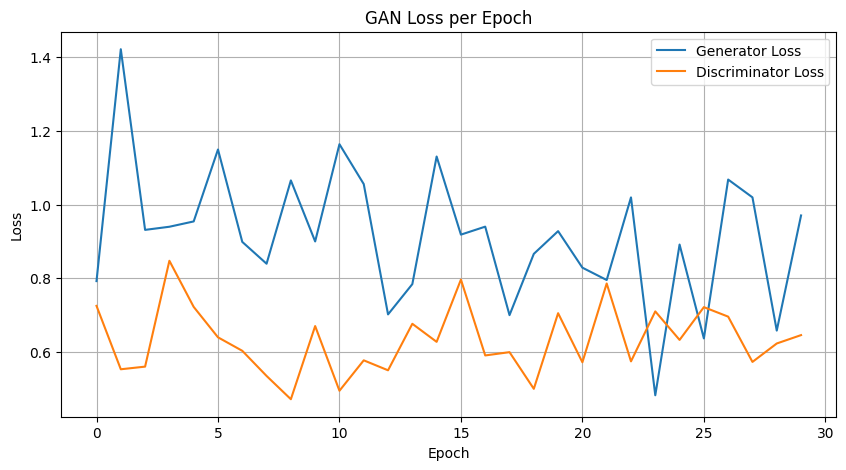

In [10]:
df = pd.read_csv(log_path)

plt.figure(figsize=(10,5))
plt.plot(df["epoch"], df["G_loss"], label="Generator Loss")
plt.plot(df["epoch"], df["D_loss"], label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

## Wasserstein GAN

In [11]:
# We use the same generator as Vanilla GAN

class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # 1 x 28 x 28
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias = False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),

            # 64 x 14 x 14
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias = False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace = True),
            nn.Dropout2d(0.25),

            # 128 x 7 x 7
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias = False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace = True),
            nn.Dropout2d(0.25),

            # 256 x 4 x 4
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=0, bias = False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace = True),

            # 512 x 2 x 2 
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512*2*2, 1)
        )

    def forward(self, x):
        return self.fc(self.main(x).view(x.size(0), -1))



In [24]:

# WGAN hyperparameters
lr = 1e-5
CRITIC_ITERATIONS = 10      
WEIGHT_CLIP = 0.005         

In [25]:
critic = Critic().to(device)
generator = Generator(latent_dim=LATENT_DIM).to(device)

# RMSprop instead of Adam - suggested in original paper
opt_critic = optim.RMSprop(critic.parameters(), lr=lr)
opt_generator = optim.RMSprop(generator.parameters(), lr=3*lr)

criterion = None

fixed_noise = torch.randn(BATCH_SIZE, LATENT_DIM).to(device)

In [26]:
writer_fake = SummaryWriter("runs/WGAN_MNIST/fake")
writer_real = SummaryWriter("runs/WGAN_MNIST/real")

In [27]:
step = 0
print("Started WGAN Training...")

log_path = "wgan_losses.csv"

if not os.path.exists(log_path):
    with open(log_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["epoch", "G_loss", "C_loss"])


save_epoch_snapshot(generator, fixed_noise, epoch=0, device=device, save_dir="plots/progression_wgan")

for epoch in range(EPOCHS):
    print()
    for batch_idx, (real, _) in enumerate(loader):
        real = real.to(device)
        batch_size = real.shape[0]


        for _ in range(CRITIC_ITERATIONS):
            noise = torch.randn(batch_size, LATENT_DIM).to(device)
            fake = generator(noise)

            critic_real = critic(real)
            critic_fake = critic(fake.detach())

            # Wasserstein Loss
            loss_critic = -(torch.mean(critic_real) - torch.mean(critic_fake)) # maximizing real scores and minimizing fake scores

            opt_critic.zero_grad()
            loss_critic.backward()
            opt_critic.step()

            for p in critic.parameters():
                p.data.clamp_(-WEIGHT_CLIP, WEIGHT_CLIP)

        # Train Generator
        noise = torch.randn(batch_size, LATENT_DIM).to(device)
        fake = generator(noise)
        critic_fake = critic(fake)
        loss_generator = -torch.mean(critic_fake)

        opt_generator.zero_grad()
        loss_generator.backward()
        opt_generator.step()

        print(
            f"\rEpoch [{epoch+1}/{EPOCHS}] Batch {batch_idx}/{len(loader)} "
            f"Loss Critic: {loss_critic:.4f}, Loss Generator: {loss_generator:.4f}",
            end=""
        )

        if batch_idx % LOG_STEP == 0:
            with torch.no_grad():
                fake_display = generator(fixed_noise).reshape(-1, 1, 28, 28)
                data = real.reshape(-1, 1, 28, 28)
                imgGridFake = torchvision.utils.make_grid(fake_display, normalize=True)
                imgGridReal = torchvision.utils.make_grid(data, normalize=True)

                writer_fake.add_image("MNIST Fake Images", imgGridFake, global_step=step)
                writer_real.add_image("MNIST Real Images", imgGridReal, global_step=step)
                writer_fake.add_scalar("Loss/Generator", loss_generator, global_step=step)
                writer_real.add_scalar("Loss/Critic", loss_critic, global_step=step)

                step += 1

    with open(log_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([epoch, loss_generator.item(), loss_critic.item()])

    save_epoch_snapshot(generator, fixed_noise, epoch=epoch+1, device=device, save_dir="plots/progression_wgan")

Started WGAN Training...

Epoch [1/30] Batch 937/938 Loss Critic: -0.0475, Loss Generator: 0.01696
Epoch [2/30] Batch 937/938 Loss Critic: -0.0275, Loss Generator: 0.01359
Epoch [3/30] Batch 937/938 Loss Critic: -0.0233, Loss Generator: -0.0047
Epoch [4/30] Batch 937/938 Loss Critic: -0.0289, Loss Generator: 0.00973
Epoch [5/30] Batch 937/938 Loss Critic: -0.0283, Loss Generator: 0.01247
Epoch [6/30] Batch 937/938 Loss Critic: -0.0245, Loss Generator: 0.00164
Epoch [7/30] Batch 937/938 Loss Critic: -0.0237, Loss Generator: 0.00431
Epoch [8/30] Batch 937/938 Loss Critic: -0.0201, Loss Generator: 0.00196
Epoch [9/30] Batch 937/938 Loss Critic: -0.0183, Loss Generator: 0.01258
Epoch [10/30] Batch 937/938 Loss Critic: -0.0306, Loss Generator: -0.0006
Epoch [11/30] Batch 937/938 Loss Critic: -0.0286, Loss Generator: 0.00702
Epoch [12/30] Batch 937/938 Loss Critic: -0.0172, Loss Generator: 0.00015
Epoch [13/30] Batch 937/938 Loss Critic: -0.0116, Loss Generator: 0.00038
Epoch [14/30] Batch 9

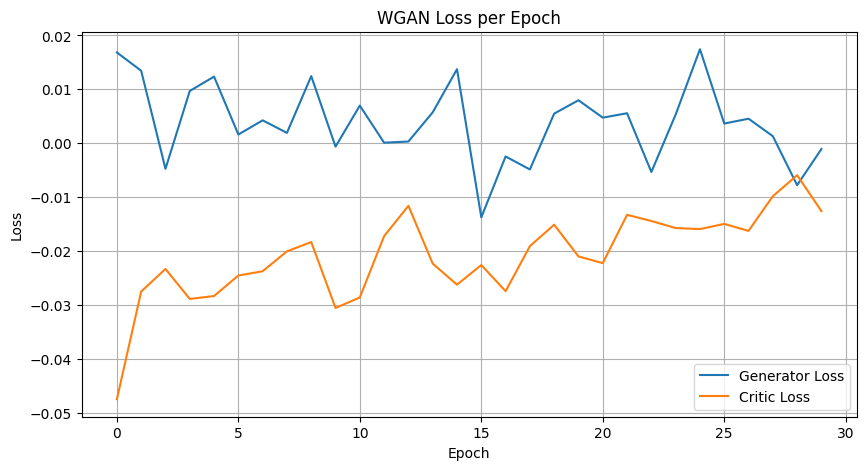

In [28]:
df = pd.read_csv(log_path)

plt.figure(figsize=(10,5))
plt.plot(df["epoch"], df["G_loss"], label="Generator Loss")
plt.plot(df["epoch"], df["C_loss"], label="Critic Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("WGAN Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()